RNN

(Monthly Milk Production Forecasting 
Using RNN, LSTM, and GRU Deep Learning Models)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

1.	Exploratory Data Analysis (EDA)

In [7]:
df = pd.read_csv("monthly_milk_production.csv")

df.head()


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [13]:
df.isnull().sum()

Production    0
dtype: int64

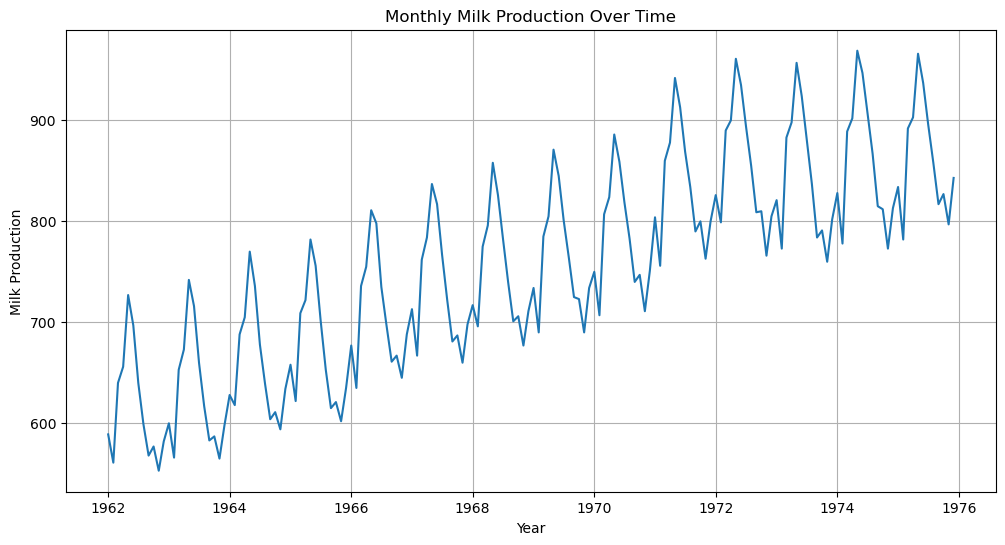

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df['Production'])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

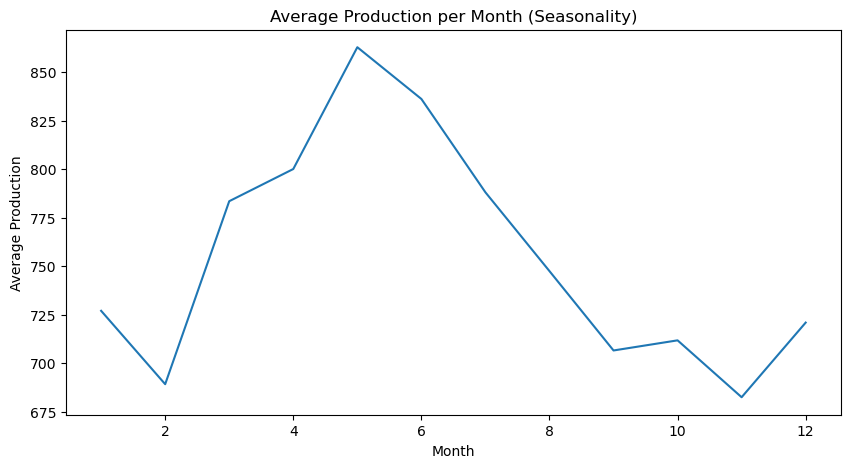

In [17]:
df['Month_Number'] = df.index.month

monthly_avg = df.groupby('Month_Number')['Production'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg)
plt.title("Average Production per Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.show()


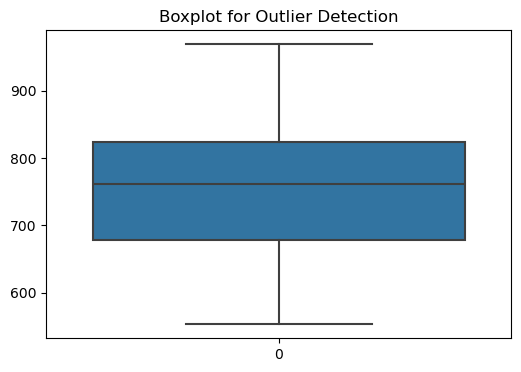

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(df['Production'])
plt.title("Boxplot for Outlier Detection")
plt.show()


In [21]:
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Production'] < lower_bound) | (df['Production'] > upper_bound)]

print("Number of Outliers:", len(outliers))
outliers.head()


Number of Outliers: 0


,Production,Month_Number
Date,,


In [23]:
df.isnull().sum()


Production      0
Month_Number    0
dtype: int64

In [25]:
df.fillna(method='ffill', inplace=True)


In [27]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

scaled_df = pd.DataFrame(scaled_data, 
                         index=df.index, 
                         columns=['Production'])

scaled_df.head()


,Production
Date,
1962-01-01,0.086538
1962-02-01,0.019231
1962-03-01,0.209135
1962-04-01,0.247596
1962-05-01,0.418269


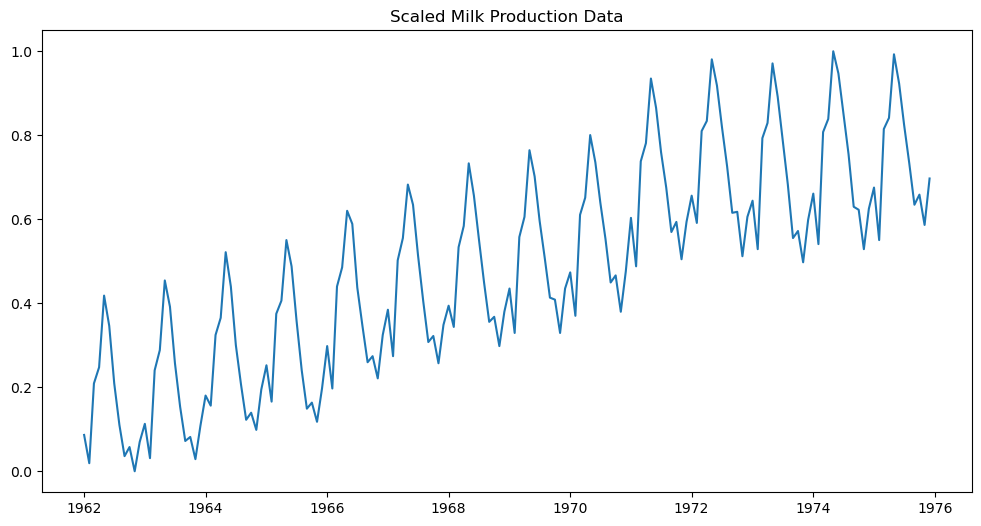

In [29]:
plt.figure(figsize=(12,6))
plt.plot(scaled_df)
plt.title("Scaled Milk Production Data")
plt.show()


2.	Data Preparation for Deep Learning

In [32]:
scaled_df

,Production
Date,
1962-01-01,0.086538
1962-02-01,0.019231
1962-03-01,0.209135
1962-04-01,0.247596
1962-05-01,0.418269
...,...
1975-08-01,0.733173
1975-09-01,0.634615
1975-10-01,0.658654


In [34]:
data = scaled_df['Production'].values

In [36]:
def create_sequences(data, window_size):
    X = []
    y = []
    
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
        
    return np.array(X), np.array(y)


In [38]:
window_size = 12  # 12 months

data = scaled_df['Production'].values

X, y = create_sequences(data, window_size)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (156, 12)
Shape of y: (156,)


In [40]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]


In [42]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (109, 12)
Validation set: (23, 12)
Test set: (24, 12)


In [44]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [46]:
print("Final Training shape:", X_train.shape)
print("Final Validation shape:", X_val.shape)
print("Final Test shape:", X_test.shape)


Final Training shape: (109, 12, 1)
Final Validation shape: (23, 12, 1)
Final Test shape: (24, 12, 1)


3.	Model Building

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [50]:
units = 64          
batch_size = 16
epochs = 100
learning_rate = 0.001


In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [52]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(units=units, 
                        activation='tanh', 
                        input_shape=(window_size, 1)))

rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.1289 - val_loss: 0.0409
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0418 - val_loss: 0.0536
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0234 - val_loss: 0.0063
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0172 - val_loss: 0.0058
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0104 - val_loss: 0.0136
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0105 - val_loss: 0.0062
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0075 - val_loss: 0.0049
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0079 - val_loss: 0.0049
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0070 - val_loss: 0.0066
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0067 - val_loss: 0.0037
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0049 - val_loss: 0.0034
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0059 - val_l

In [59]:
lstm_model = Sequential()

lstm_model.add(LSTM(units=units,
                    activation='tanh',
                    input_shape=(window_size, 1)))

lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
lstm_model = Sequential()

lstm_model.add(LSTM(units=units,
                    activation='tanh',
                    input_shape=(window_size, 1)))

lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
gru_model = Sequential()

gru_model.add(GRU(units=units,
                  activation='tanh',
                  input_shape=(window_size, 1)))

gru_model.add(Dropout(0.2))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - loss: 0.1461 - val_loss: 0.1895
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0534 - val_loss: 0.0317
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0378 - val_loss: 0.0276
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0340 - val_loss: 0.0353
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0232 - val_loss: 0.0458
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0255 - val_loss: 0.0435
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0264 - val_loss: 0.0337
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0271 - val_loss: 0.0307
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0268 - val_loss: 0.0314
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0241 - val_loss: 0.0317


In [66]:
units = 32
units = 128

window_size = 6
window_size = 24

batch_size = 32

epochs = 150


4.	Model Evaluationm

In [68]:
# Predictions
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


In [72]:
# Reshape y_test for inverse transform
y_test_reshaped = y_test.reshape(-1, 1)

# Inverse transform
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test_reshaped)


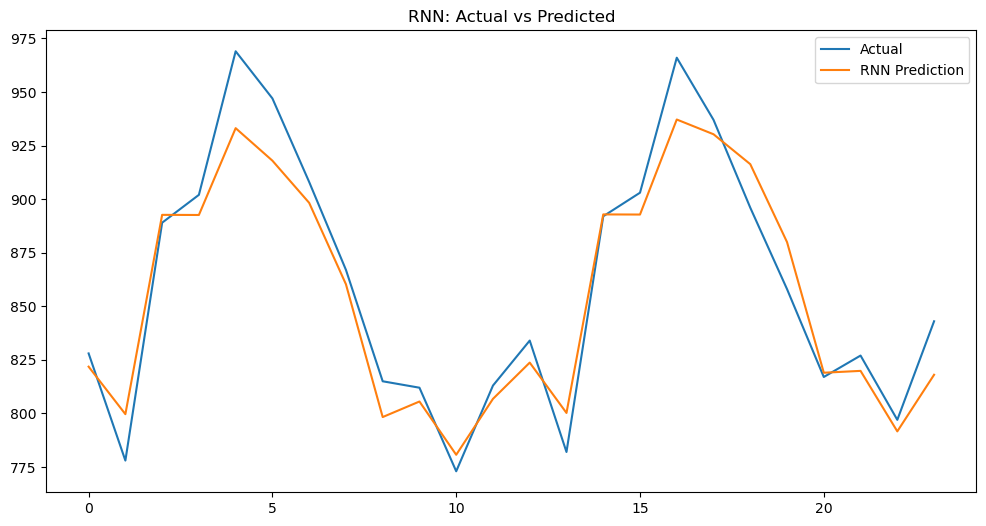

In [74]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred, label="RNN Prediction")
plt.title("RNN: Actual vs Predicted")
plt.legend()
plt.show()

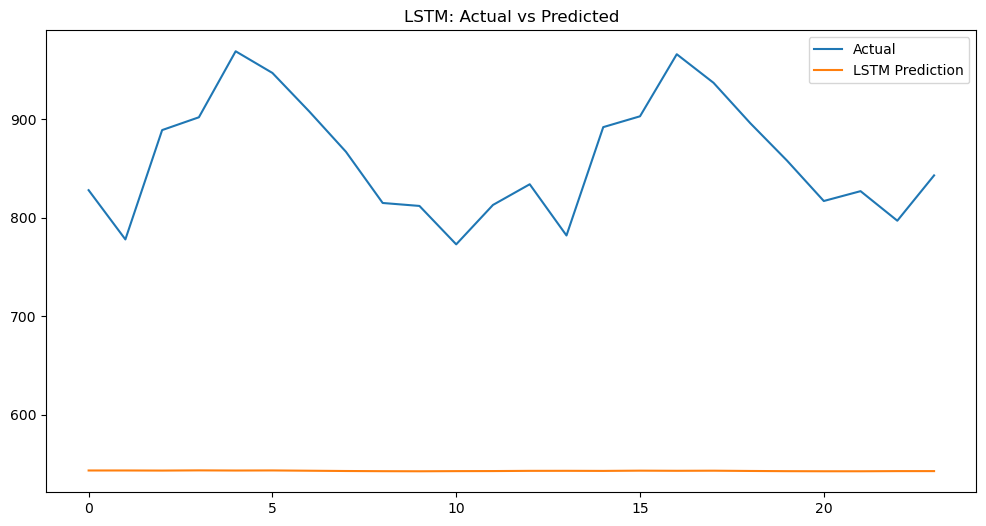

In [76]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.title("LSTM: Actual vs Predicted")
plt.legend()
plt.show()

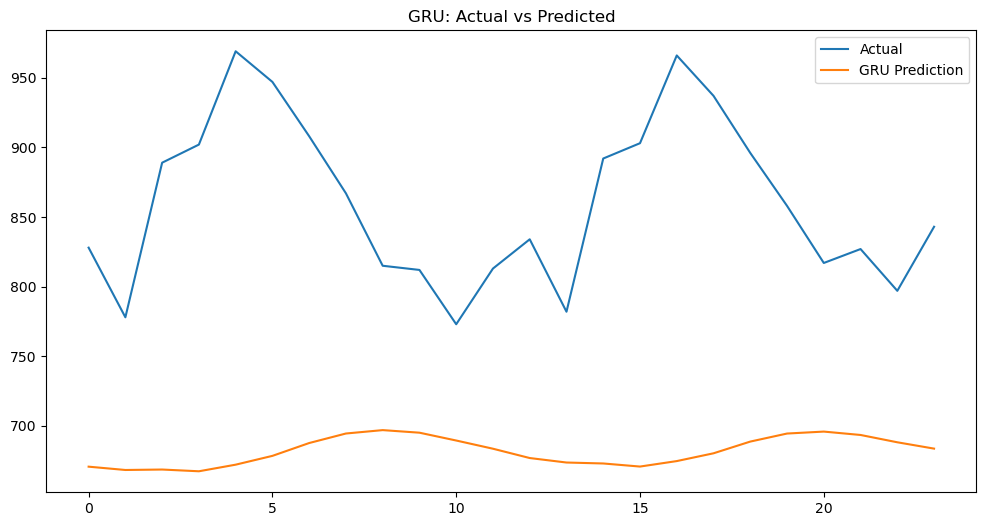

In [78]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(gru_pred, label="GRU Prediction")
plt.title("GRU: Actual vs Predicted")
plt.legend()
plt.show()


In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(actual, predicted):
    rnn_rmse = np.sqrt(mean_squared_error(actual, predicted))
    rnn_mae = mean_absolute_error(actual, predicted)
    rnn_mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return rnn_rmse, rnn_mae, rnn_mape

In [82]:
y_test
rnn_pred

array([[821.816  ],
       [799.653  ],
       [892.6622 ],
       [892.6055 ],
       [933.11926],
       [917.94727],
       [898.2662 ],
       [860.2839 ],
       [798.30255],
       [805.55444],
       [780.703  ],
       [806.79803],
       [823.71277],
       [800.22235],
       [892.8678 ],
       [892.80945],
       [937.1572 ],
       [930.2763 ],
       [916.3164 ],
       [879.9408 ],
       [818.98846],
       [819.8537 ],
       [791.62256],
       [818.0364 ]], dtype=float32)

In [84]:
rnn_rmse, rnn_mae, rnn_mape = evaluate_model(y_test, rnn_pred)
lstm_rmse, lstm_mae, lstm_mape = evaluate_model(y_test, rnn_pred)
gru_rmse, gru_mae, gru_mape = evaluate_model(y_test, rnn_pred)

In [86]:
print("RNN Performance:")
print("RMSE:", rnn_rmse)
print("MAE:", rnn_mae)
print("MAPE:", rnn_mape)

print("\nLSTM Performance:")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

print("\nGRU Performance:")
print("RMSE:", gru_rmse)
print("MAE:", gru_mae)
print("MAPE:", gru_mape)


RNN Performance:
RMSE: 856.2081052235484
MAE: 854.657196436173
MAPE: 119807.22579622961

LSTM Performance:
RMSE: 856.2081052235484
MAE: 854.657196436173
MAPE: 119807.22579622961

GRU Performance:
RMSE: 856.2081052235484
MAE: 854.657196436173
MAPE: 119807.22579622961


In [88]:
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "MAPE": [rnn_mape, lstm_mape, gru_mape]
})

comparison


,Model,RMSE,MAE,MAPE
0,RNN,856.208105,854.657196,119807.225796
1,LSTM,856.208105,854.657196,119807.225796
2,GRU,856.208105,854.657196,119807.225796


5.	Prediction and Visualization

In [91]:
scaled_df  
scaler  
window_size = 12

In [ ]:
future_steps = 12

# Get last window from scaled data
last_window = scaled_df['Production'].values[-window_size:]

future_predictions = []

current_input = last_window.reshape(1, window_size, 1)

for _ in range(future_steps):
    
    pred = lstm_model.predict(current_input)
    
    future_predictions.append(pred[0][0])
    
    # Update input window
    current_input = np.append(
        current_input[:, 1:, :],
        [[[pred[0][0]]]],
        axis=1
    )

future_predictions = np.array(future_predictions).reshape(-1,1)

# Inverse scale
future_predictions = scaler.inverse_transform(future_predictions)


In [170]:
last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=13,
    freq='M'
)[1:]


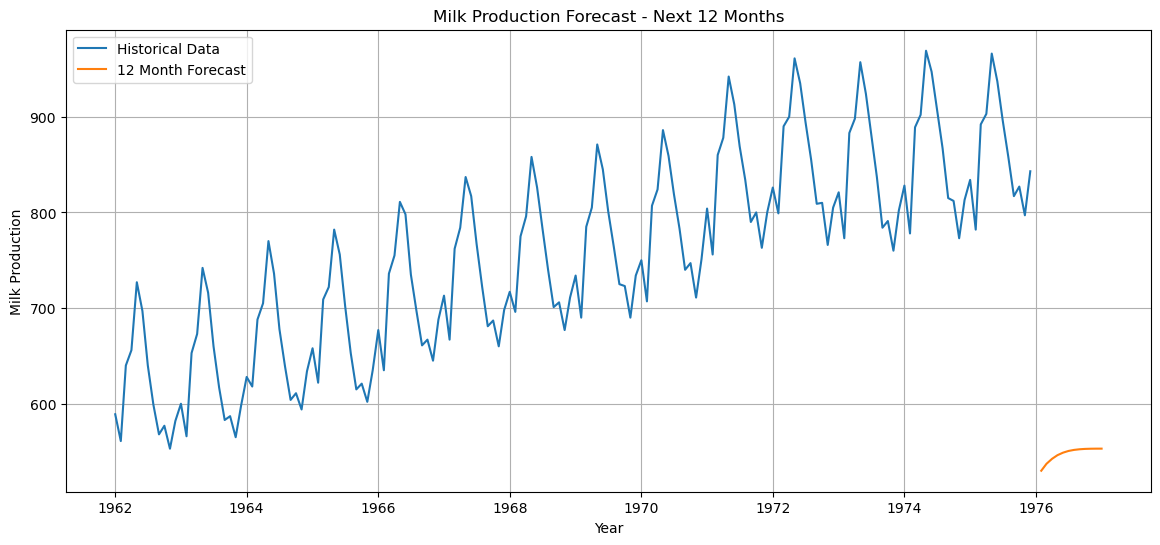

In [173]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Production'], label="Historical Data")
plt.plot(future_dates, future_predictions, label="12 Month Forecast")

plt.title("Milk Production Forecast - Next 12 Months")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()


In [208]:
rmse = lstm_rmse   

upper_bound = future_predictions + rmse
lower_bound = future_predictions - rmse


In [210]:
future_predictions = future_predictions.ravel()
lower_bound = lower_bound.ravel()
upper_bound = upper_bound.ravel()

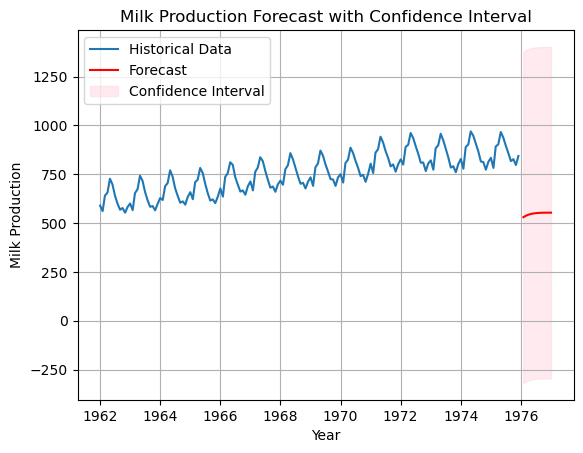

In [212]:
plt.plot(df.index, df['Production'], label="Historical Data")
plt.plot(future_dates, future_predictions, label="Forecast", color='red')

plt.fill_between(
    future_dates,
    lower_bound,
    upper_bound,
    color='pink',
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("Milk Production Forecast with Confidence Interval")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()


In [194]:
print(future_predictions.shape)
print(lower_bound.shape)
print(upper_bound.shape)

(12,)
(12,)
(12,)


In [179]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Production": future_predictions.flatten(),
    "Lower Bound": lower_bound.flatten(),
    "Upper Bound": upper_bound.flatten()
})

forecast_df


,Date,Predicted Production,Lower Bound,Upper Bound
0,1976-01-31,529.988281,-318.506104,1378.482666
1,1976-02-29,537.231934,-311.262451,1385.726318
2,1976-03-31,542.446045,-306.048340,1390.940430
3,1976-04-30,546.244446,-302.249939,1394.738770
4,1976-05-31,548.879028,-299.615356,1397.373413
5,1976-06-30,550.635864,-297.858521,1399.130249
6,1976-07-31,551.750061,-296.744324,1400.244385
7,1976-08-31,552.418945,-296.075439,1400.913330
8,1976-09-30,552.792297,-295.702087,1401.286621
9,1976-10-31,552.978699,-295.515686,1401.473145


6.	Business Insights